# Seaborn Matrix, Joint Distributions & Facet Grids (5+ Years Interview Guide)
Exhaustive revision guide with dedicated separate cells for correlation heatmaps, hierarchical clustermaps, jointplot, JointGrid, FacetGrid, pairplot, and PairGrid on raw_transactions.csv.

### Key 5-Year Interview Concepts Covered:
- **Matrix Visualizations**: Dedicated separate cells for `sns.heatmap()` with annotations and `sns.clustermap()`.
- **Joint Distributions**: Dedicated separate cells for `sns.jointplot()` and custom `sns.JointGrid()` configurations.
- **Conditional Faceting**: Dedicated separate cell for `sns.FacetGrid(df, col=...)` chained with `.map()`.
- **Multi-Variable Pairs**: Dedicated separate cells for `sns.pairplot()` and custom `sns.PairGrid()`.

This interactive revision guide uses `data/raw_transactions.csv` with 1-to-1 atomic method cells and rich inline visual outputs.

In [1]:
# Setup imports & dataset loading from raw_transactions.csv
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import sys

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"Loaded {len(df)} cleaned transaction records from {csv_path}")

Loaded 14262 cleaned transaction records from data/raw_transactions.csv


### Correlation Heatmap: `sns.heatmap()`
**Explanation**: Renders 2D correlation matrix with numeric cell annotations, colormap gradients, and colorbars.

**Syntax**: `sns.heatmap(corr_df, annot=True, cmap='coolwarm', cbar=True)`

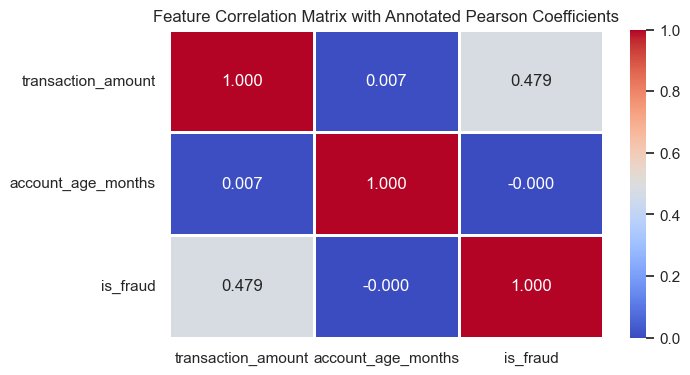

In [2]:
corr = df[['transaction_amount', 'account_age_months', 'is_fraud']].corr()
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', cbar=True, linewidths=1, ax=ax)
ax.set_title('Feature Correlation Matrix with Annotated Pearson Coefficients')
plt.show()

### Hierarchical Clustermap: `sns.clustermap()`
**Explanation**: Performs hierarchical agglomerative clustering along rows and columns displaying dendrogram trees.

**Syntax**: `sns.clustermap(pivot_table, cmap='viridis')`

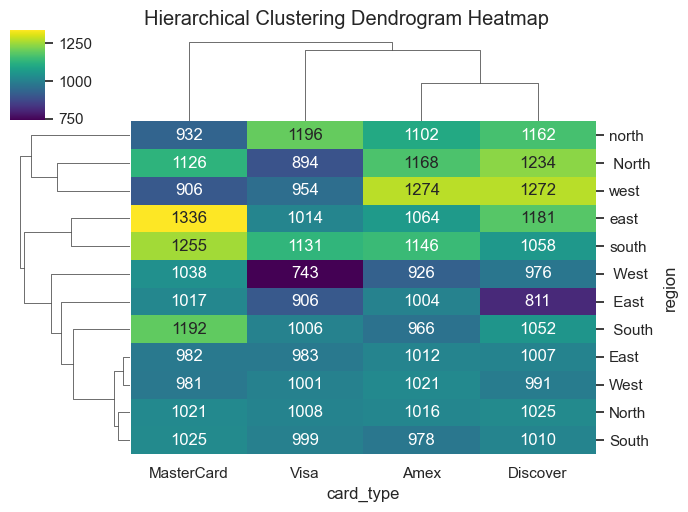

In [3]:
piv = df.pivot_table(index='region', columns='card_type', values='transaction_amount', aggfunc='mean')
g = sns.clustermap(piv, cmap='viridis', annot=True, fmt='.0f', figsize=(7, 5))
g.fig.suptitle('Hierarchical Clustering Dendrogram Heatmap', y=1.02)
plt.show()

### Joint Distribution: `sns.jointplot()`
**Explanation**: Combines bivariate relationship scatter/KDE plot with univariate marginal distributions.

**Syntax**: `sns.jointplot(df, x='account_age_months', y='transaction_amount', kind='hex')`

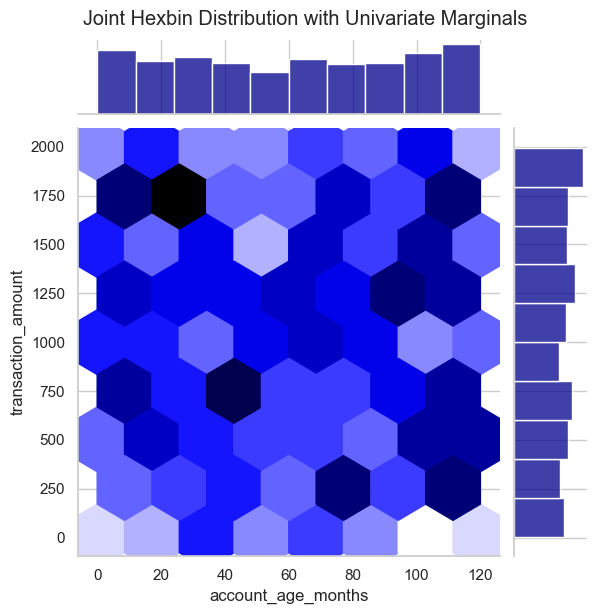

In [4]:
g = sns.jointplot(df.head(400), x='account_age_months', y='transaction_amount', kind='hex', color='darkblue', height=6)
g.fig.suptitle('Joint Hexbin Distribution with Univariate Marginals', y=1.02)
plt.show()

### Customized Joint Grid: `sns.JointGrid()`
**Explanation**: Provides fine-grained programmatic control over joint and marginal subplots.

**Syntax**: `g = sns.JointGrid(df, x=..., y=...); g.plot_joint(...); g.plot_marginals(...)`

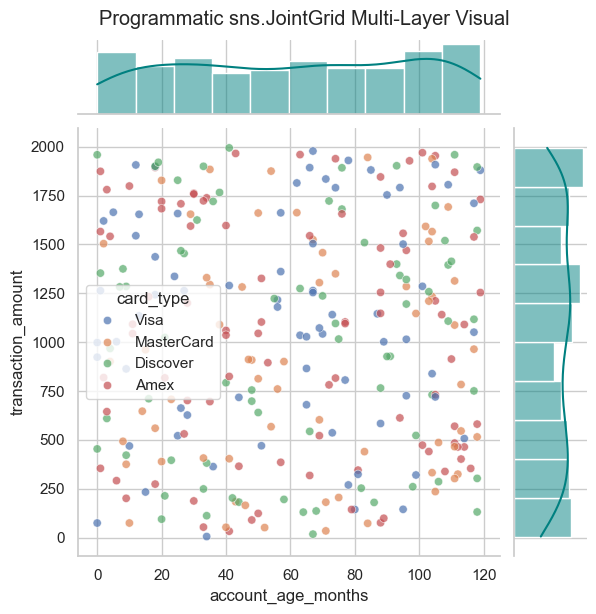

In [5]:
g = sns.JointGrid(data=df.head(300), x='account_age_months', y='transaction_amount', height=6)
g.plot_joint(sns.scatterplot, hue=df.head(300)['card_type'], alpha=0.7)
g.plot_marginals(sns.histplot, kde=True, color='teal')
g.fig.suptitle('Programmatic sns.JointGrid Multi-Layer Visual', y=1.02)
plt.show()

### Conditional Subplot Faceting: `sns.FacetGrid()` & `.map()`
**Explanation**: Structures multi-panel subplots across categorical subsets chaining plotting calls via `.map()`.

**Syntax**: `g = sns.FacetGrid(df, col='region', row='is_fraud'); g.map(sns.histplot, 'amount')`

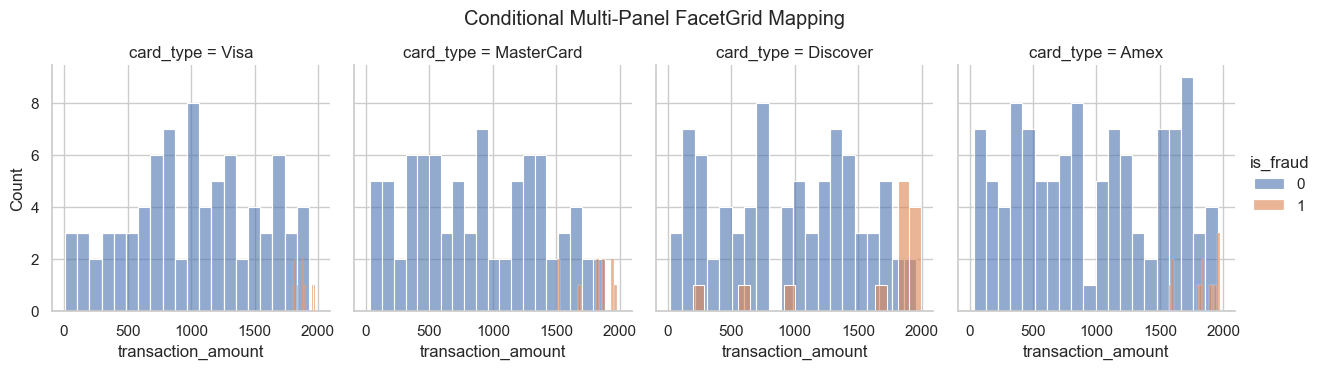

In [6]:
g = sns.FacetGrid(df.head(400), col='card_type', hue='is_fraud', height=3.5, aspect=0.9)
g.map(sns.histplot, 'transaction_amount', alpha=0.6, bins=20)
g.add_legend()
g.fig.suptitle('Conditional Multi-Panel FacetGrid Mapping', y=1.05)
plt.show()

### Pairwise Feature Matrix: `sns.pairplot()`
**Explanation**: Visualizes all pairwise numerical scatter plots with diagonal KDE/histogram distributions.

**Syntax**: `sns.pairplot(df[['amount', 'age', 'is_fraud']], hue='is_fraud')`

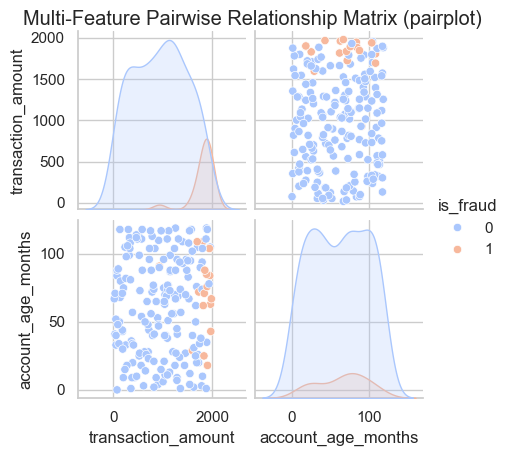

In [7]:
g = sns.pairplot(df[['transaction_amount', 'account_age_months', 'is_fraud']].head(200), hue='is_fraud', palette='coolwarm', height=2.2)
g.fig.suptitle('Multi-Feature Pairwise Relationship Matrix (pairplot)', y=1.02)
plt.show()

### Customized Pair Grid: `sns.PairGrid()`
**Explanation**: Customizes diagonal, upper triangle, and lower triangle subplots independently.

**Syntax**: `g = sns.PairGrid(df); g.map_upper(sns.scatterplot); g.map_diag(sns.kdeplot)`

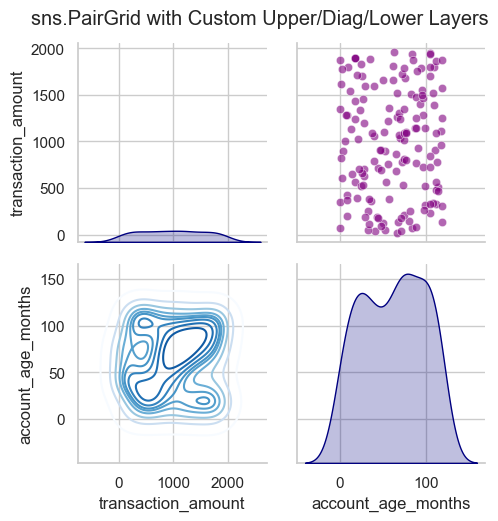

In [8]:
g = sns.PairGrid(df[['transaction_amount', 'account_age_months']].head(150), height=2.5)
g.map_upper(sns.scatterplot, color='purple', alpha=0.6)
g.map_diag(sns.kdeplot, fill=True, color='navy')
g.map_lower(sns.kdeplot, cmap='Blues')
g.fig.suptitle('sns.PairGrid with Custom Upper/Diag/Lower Layers', y=1.03)
plt.show()

## Section: Senior Fintech Interview Scenarios (5+ Years Experience)

### Q1: Correlation vs Distance Metrics in Clustermaps
**Explanation**: Explain how hierarchical clustering dendrograms compute pairwise distances (Euclidean vs Ward linkage) on pivoted financial matrices.

**Syntax**: `sns.clustermap(metric='euclidean', method='ward')`

In [9]:
print('Clustermap calculates distance matrices via scipy.spatial.distance before reordering matrix rows and columns.')

Clustermap calculates distance matrices via scipy.spatial.distance before reordering matrix rows and columns.
